In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

In [2]:
from locallib.picarrodb import *
from locallib.query import *
import pandas as pd

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


In [3]:
a = get_users(customer_name = 'ENBW', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2025-01-01')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU1_Conn, table_return = ['#TempPeak', '#TempSurvey'])

In [4]:
peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])

In [5]:
peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

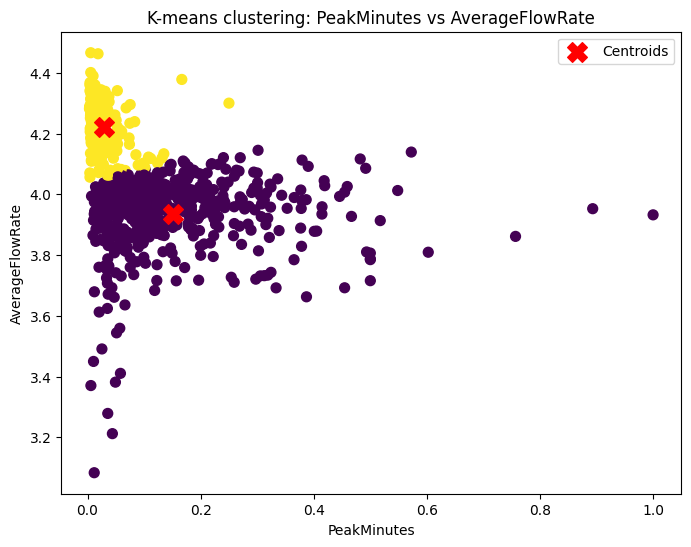

In [19]:
total = peak_survey.copy()
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

X = total[['PeakMinutes', 'AverageFlowRate']].values

# Let's assume 3 clusters, you may adjust this as needed
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

total['Cluster'] = kmeans.labels_

# Plotting the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    cupra['PeakMinutes'], cupra['AverageFlowRate'],
    c=cupra['Cluster'], cmap='viridis', s=50
)
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    s=200, c='red', marker='X', label='Centroids'
)
plt.xlabel('PeakMinutes')
plt.ylabel('AverageFlowRate')
plt.title('K-means clustering: PeakMinutes vs AverageFlowRate')
plt.legend()
plt.show()

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/sklearn/base.py:438: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
/tmp/ipykernel_27686/354641107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cupra['Cluster'] = kmeans.predict(cupra[['PeakMinutes', 'AverageFlowRate']])


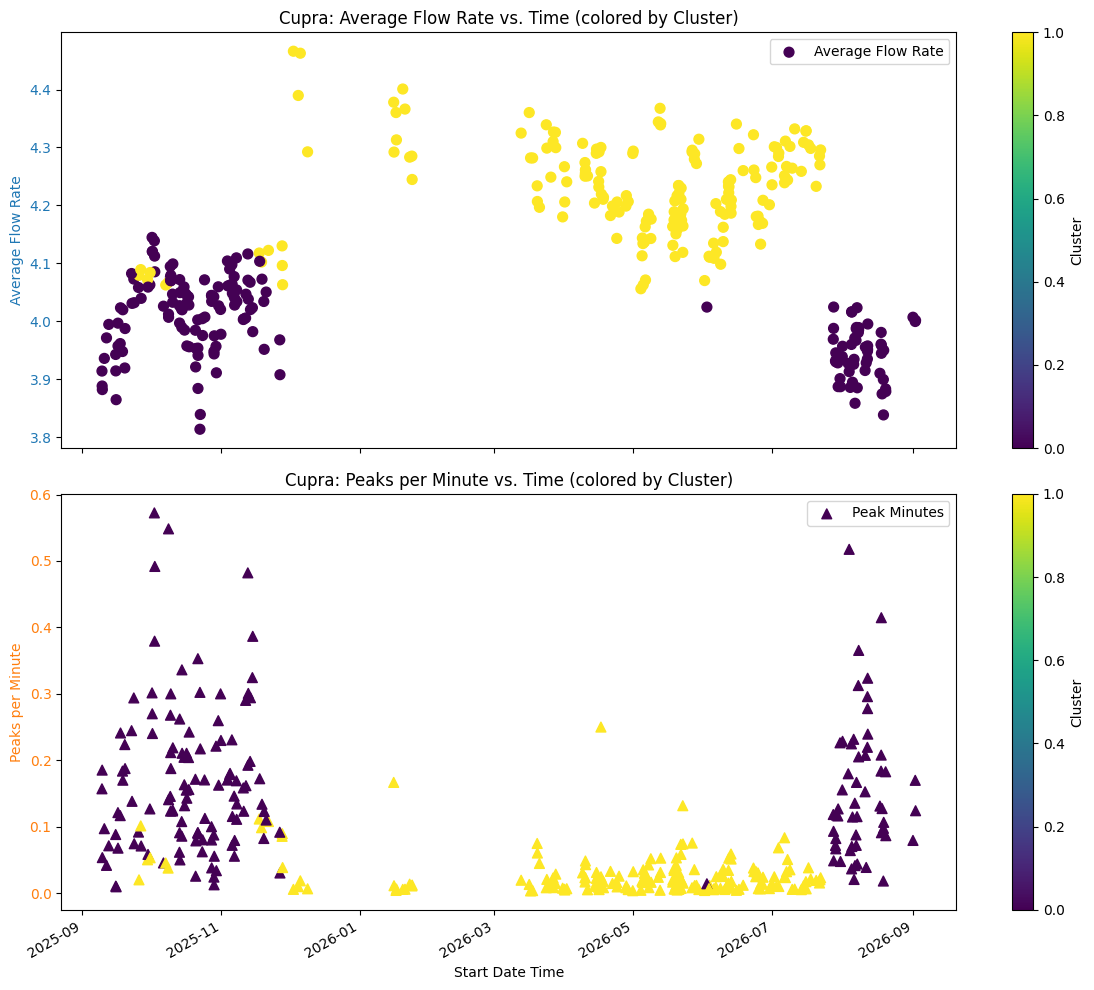

In [23]:
cupra = peak_survey[peak_survey['SurveyorUnit'] == 'ENBW - Cupra']
cupra['Cluster'] = kmeans.predict(cupra[['PeakMinutes', 'AverageFlowRate']])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Subplot 1: Average Flow Rate vs Time
scatter1 = ax1.scatter(
    cupra['StartDateTime'],
    cupra['AverageFlowRate'],
    c=cupra['Cluster'], cmap='viridis', s=50, label='Average Flow Rate'
)
ax1.set_ylabel('Average Flow Rate', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Cupra: Average Flow Rate vs. Time (colored by Cluster)')
ax1.legend()

cbar1 = plt.colorbar(scatter1, ax=ax1, orientation='vertical', label='Cluster')

# Subplot 2: Peaks per Minute vs Time
scatter2 = ax2.scatter(
    cupra['StartDateTime'],
    cupra['PeakMinutes'],
    c=cupra['Cluster'], cmap='viridis', s=50, marker='^', label='Peak Minutes'
)
ax2.set_xlabel('Start Date Time')
ax2.set_ylabel('Peaks per Minute', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_title('Cupra: Peaks per Minute vs. Time (colored by Cluster)')
ax2.legend()

cbar2 = plt.colorbar(scatter2, ax=ax2, orientation='vertical', label='Cluster')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()